# Travel, Tourism & Hospitality

## Customer Retention and Dynamic Pricing Analysis

### Week 2 - Day 3

ADR vs Cancellation Analysis

Dataset:
Hotel Booking Demand Dataset

Author:
Niveditha J

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\hotel_bookings_validated.csv"
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,total_guests,booking_changed,has_previous_cancellation,special_request_flag
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,1,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,1,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2.0,0,0,1


In [3]:
df.shape

(87359, 36)

## ADR and Cancellation

ADR (Average Daily Rate) represents the average revenue earned per room.

This analysis investigates whether room pricing influences customer cancellation behavior.

In [4]:
df.groupby('is_canceled')['adr'].mean()

is_canceled
0    101.178752
1    116.311640
Name: adr, dtype: float64

In [5]:
adr_summary = df.groupby('is_canceled').agg({
    'adr':'mean'
})

adr_summary

,adr
is_canceled,
0,101.178752
1,116.311640


## Average ADR Comparison

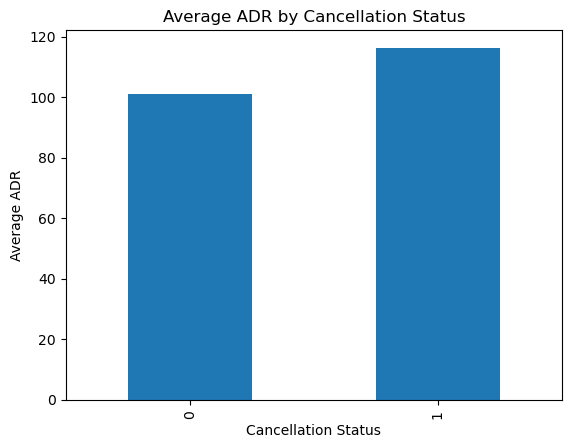

In [6]:
adr_summary.plot(
    kind='bar',
    legend=False
)

plt.title(
    "Average ADR by Cancellation Status"
)

plt.xlabel(
    "Cancellation Status"
)

plt.ylabel(
    "Average ADR"
)

plt.show()

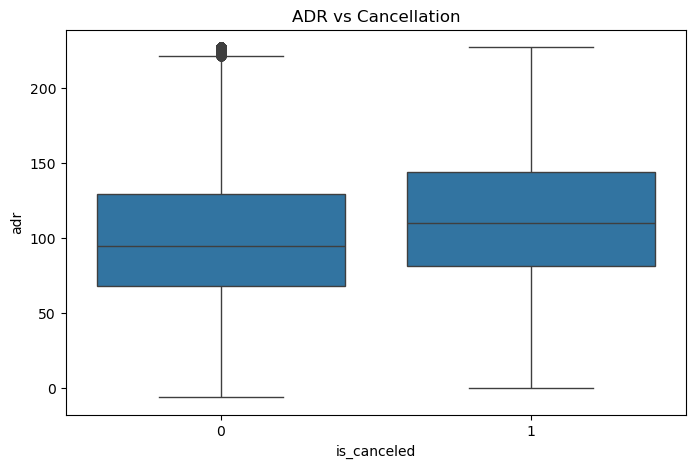

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='adr',
    data=df
)

plt.title(
    "ADR vs Cancellation"
)

plt.show()

## ADR Distribution by Cancellation Status

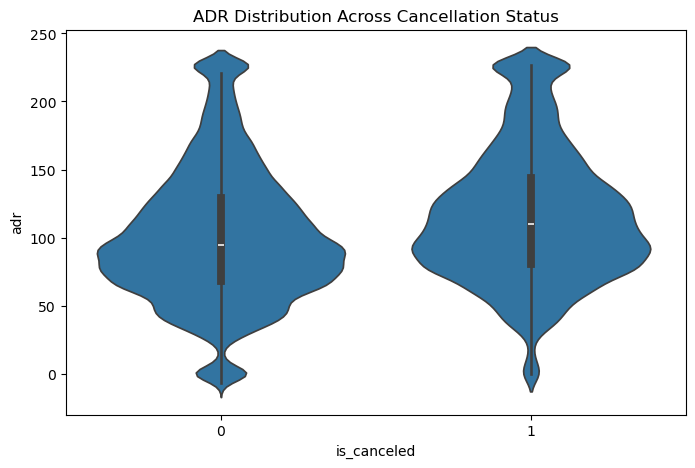

In [8]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='is_canceled',
    y='adr',
    data=df
)

plt.title(
    "ADR Distribution Across Cancellation Status"
)

plt.show()

In [9]:
df['adr_group'] = pd.qcut(
    df['adr'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [16]:
adr_cancel_rate = (
    df.groupby('adr_group', observed=False)['is_canceled']
      .mean()
      .mul(100)
      .round(2)
)

adr_cancel_rate

adr_group
Low          17.82
Medium       26.18
High         31.53
Very High    34.49
Name: is_canceled, dtype: float64

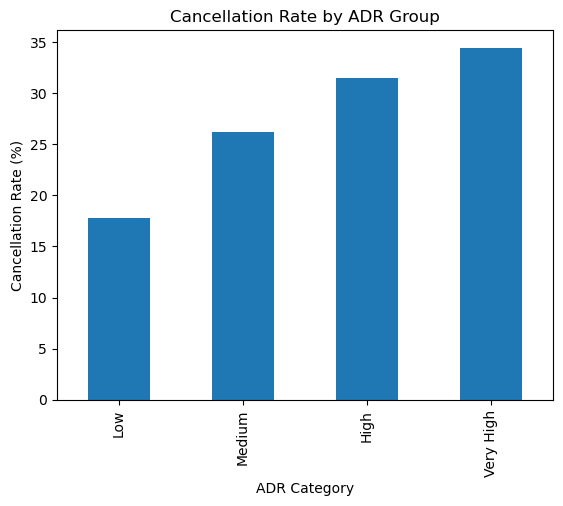

In [11]:
adr_cancel_rate.plot(
    kind='bar'
)

plt.title(
    "Cancellation Rate by ADR Group"
)

plt.xlabel(
    "ADR Category"
)

plt.ylabel(
    "Cancellation Rate (%)"
)

plt.show()

In [12]:
df.groupby('is_canceled')['adr'].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,63336.0,101.178752,48.780033,-6.38,68.0,94.5,129.1525,227.0
1,24023.0,116.311640,48.491405,0.00,81.0,109.8,144.0000,227.0


## Business Interpretation

Higher room prices may increase cancellation probability if customers find alternative options.

Understanding ADR behavior helps revenue managers balance pricing and customer retention strategies.

In [13]:
df[['adr','is_canceled']].corr()

,adr,is_canceled
adr,1.00000,0.13743
is_canceled,0.13743,1.00000


## Correlation Analysis

The correlation coefficient measures the strength of the relationship between ADR and booking cancellation.

Values closer to:

- 1 indicate strong positive relationship
- -1 indicate strong negative relationship
- 0 indicate weak relationship

## Findings

- Average ADR was compared between cancelled and retained bookings.
- ADR distributions were visualized using boxplots and violin plots.
- Cancellation rates increased across ADR categories.
- ADR and booking cancellation showed a weak positive correlation (0.137).
- Pricing behavior appears to have a limited influence on booking cancellations.

## Day 3 Conclusion

ADR was found to have a weak positive relationship with booking cancellations.

Customers paying higher room rates show slightly higher cancellation rates compared to lower-priced bookings.

These insights can support dynamic pricing decisions and customer retention strategies.